In [132]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [133]:
tf.config.run_functions_eagerly(True)
# Load the dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "complete",
    image_size=(2048, 1536),  # Resize images to 128x128
    batch_size=32,
    shuffle=True
)


Found 207 files belonging to 2 classes.


In [134]:
def crop_image_initial(image):
    print(image.shape)
    __, height, width, _ = image.shape
    cropped_image = tf.image.crop_to_bounding_box(image, 400, 400, height - 1000 , width - 800 )
    return cropped_image

In [135]:
def convert_to_grayscale(image):
    gray = tf.image.rgb_to_grayscale(image)
    return gray

In [136]:

def create_binary_mask(image, threshold):
    binary_mask = tf.where(image > threshold, 1.0, 0.0)
    return binary_mask

In [137]:
def find_centre(mask):
    positions = tf.where(mask == 1.0)
    mean_position = tf.reduce_mean(tf.cast(positions, tf.float32), axis=0)
    center_y = tf.cast(mean_position[0], tf.int32)
    center_x = tf.cast(mean_position[1], tf.int32)
    return center_y, center_x

In [138]:
def crop_around_center(image, center_y, center_x, size=600):
    half_size = size // 2
    start_y = tf.maximum(center_y - half_size, 0)
    start_x = tf.maximum(center_x - half_size, 0)
    print(f"{start_x} {start_y}")
    cropped_image = tf.image.crop_to_bounding_box(image, start_x, start_y, size, size)
    return cropped_image


In [139]:

# Define the preprocessing function

def preprocess_image(image):
    cropped_image = crop_image_initial(image)
    grayscale_img = tf.image.rgb_to_grayscale(cropped_image)
    binary_mask = tf.where(grayscale_img > 0.5, 1.0, 0.0)
    #center_y, center_x  = find_centre(binary_mask)
    mask_np = binary_mask.numpy().astype('uint8')*255
    print((mask_np))
    # print(f"{center_x} {center_y}")
    #final_cropped_image = crop_around_center(cropped_image, center_y, center_x, 500)
    #image = tf.image.resize(final_cropped_image, [224, 224])
    return binary_mask

def preprocess_image_map_fn(image, label):
    return preprocess_image(image), label

# Apply the preprocessing
dataset = dataset.map(preprocess_image_map_fn)


(None, 2048, 1536, 3)


AttributeError: in user code:

    File "C:\Users\aruna\AppData\Local\Temp\ipykernel_158940\193476947.py", line 16, in preprocess_image_map_fn  *
        return preprocess_image(image), label
    File "C:\Users\aruna\AppData\Local\Temp\ipykernel_158940\4063508730.py", line 8, in preprocess_image  *
        mask_np = binary_mask.numpy().astype('uint8')*255

    AttributeError: 'Tensor' object has no attribute 'numpy'


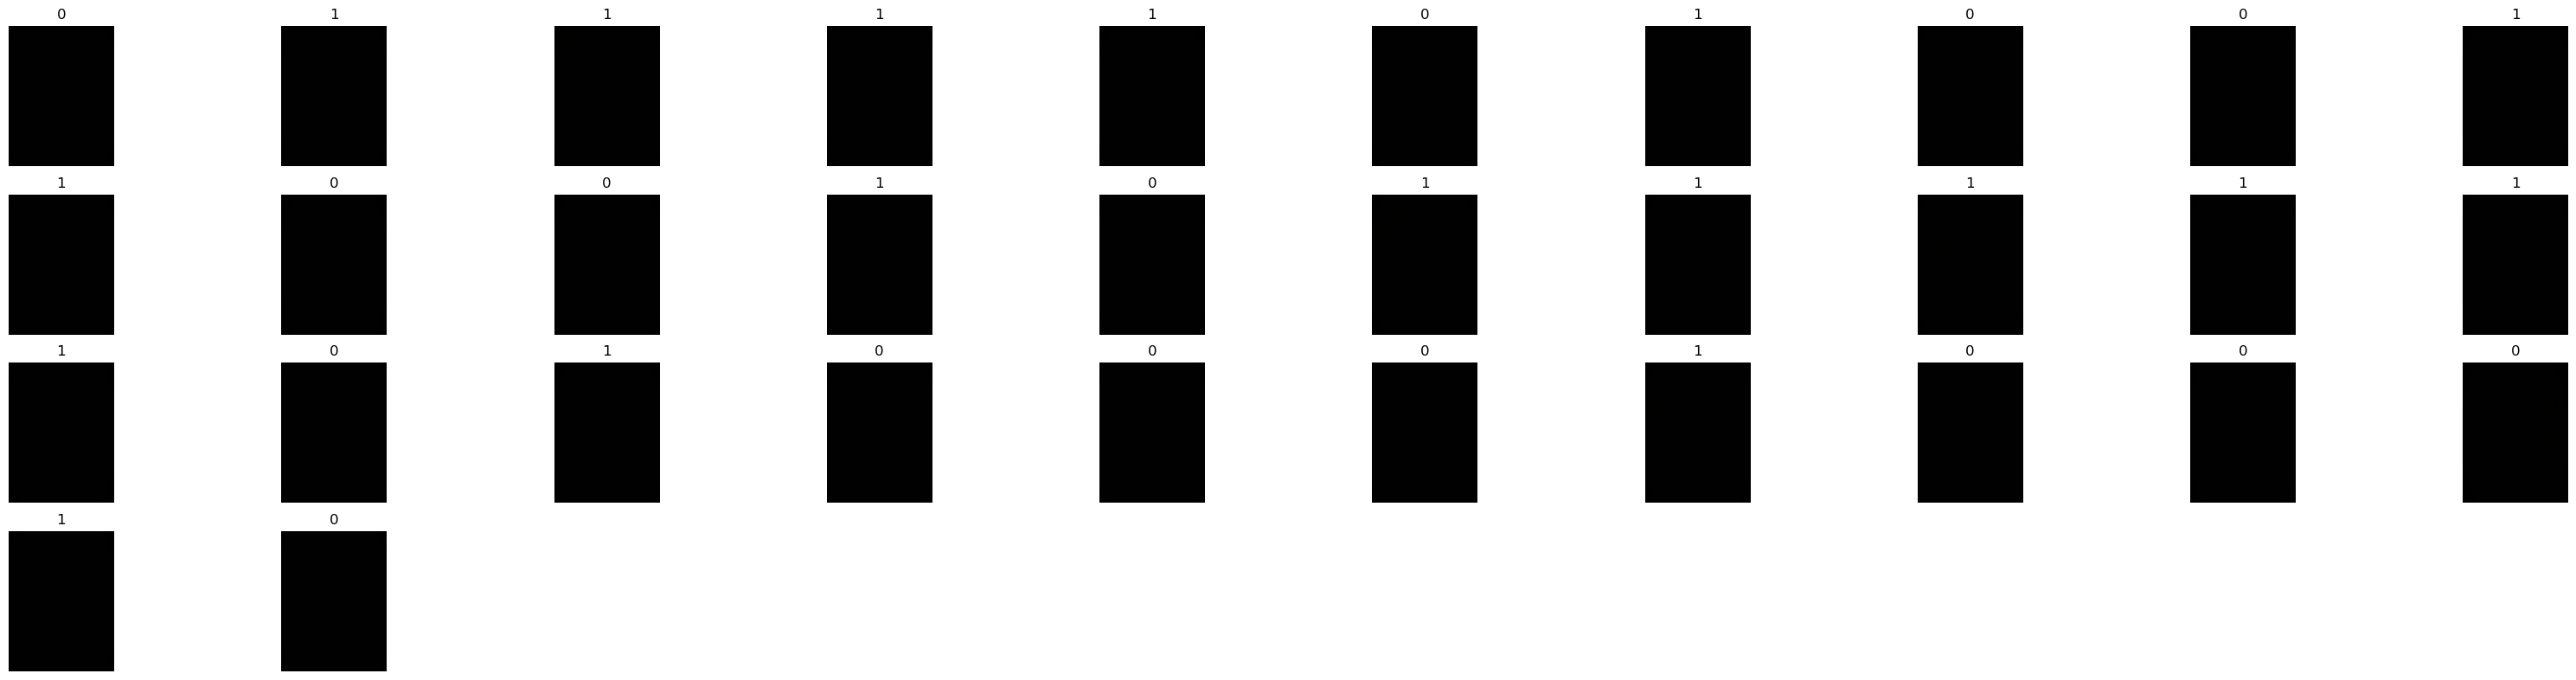

In [ ]:
plt.figure(figsize=(40, 40))
for images, labels in dataset.take(1):  # Take one batch from the dataset
    for i in range(32):
        ax = plt.subplot(16, 10, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap= "gray")
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()
